In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utility import *
from tools import *
from maps import *
from identify import *
from scipy.stats import linregress
from scipy.ndimage import maximum_filter, binary_dilation
from scipy.spatial.distance import cdist
from scipy.signal import detrend

In [2]:
# Load the Data's directory.
datadir_1 = 'C:/Users/Kevin/Desktop/26-02-17/02_01_03.zda'
datadir_2 = 'C:/Users/Kevin/Desktop/26-02-17/02_01_04.zda'

# Load the Tool Packages.
dataLoader_1 = DataLoader(datadir_1)
dataLoader_2 = DataLoader(datadir_2)
tools = Tools()
maps = Maps()
identify = Identify()

In [3]:
# Parameters setting up.
timeline = np.linspace(0, 499.5, 1000)
basePt = 190
skipPt = 100
startPt = 190
numPt = 150

In [4]:
# Data Preprocessing for data_1.
Data_1 = dataLoader_1.get_data()
Data_1 = tools.Polynomial(startPt=basePt, numPt=skipPt, Data=Data_1)
Rli_1 = dataLoader_1.get_rli()
Data_1 = tools.Rli_Division(Rli=Rli_1, Data=Data_1)
Data_1 = tools.T_filter(Data=Data_1)
Data_1 = tools.S_filter(sigma=1, Data=Data_1)
Data_ave_1 = np.mean(Data_1, axis=0)

# SNR Map for data_1. (Without Normalization)
snr_map_1 = maps.SNR_Map(startPt=startPt, numPt=numPt, Data=Data_1)

# Rli Map for data_1.
rli_high = np.array(Rli_1['rli_high'])
rli_low = np.array(Rli_1['rli_low'])

rli_1 = ((rli_high - rli_low) / 3276.8)
bad = np.where(rli_1==0)
for coor in bad:
    rli_1[coor] = 0
rli_1 = rli_1.reshape(80, 80)

In [5]:
# Data Preprocessing for data_2.
Data_2 = dataLoader_2.get_data()
Data_2 = tools.Polynomial(startPt=basePt, numPt=skipPt, Data=Data_2)
Rli_2 = dataLoader_2.get_rli()
Data_2 = tools.Rli_Division(Rli=Rli_2, Data=Data_2)
Data_2 = tools.T_filter(Data=Data_2)
Data_2 = tools.S_filter(sigma=1, Data=Data_2)
Data_ave_2 = np.mean(Data_2, axis=0)

# SNR Map for data_2. (Without Normalization)
snr_map_2 = maps.SNR_Map(startPt=startPt, numPt=numPt, Data=Data_2)

# Rli Map for data_2.
rli_high = np.array(Rli_2['rli_high'])
rli_low = np.array(Rli_2['rli_low'])

rli_2 = ((rli_high - rli_low) / 3276.8)
bad = np.where(rli_2==0)
for coor in bad:
    rli_2[coor] = 0
rli_2 = rli_2.reshape(80, 80)

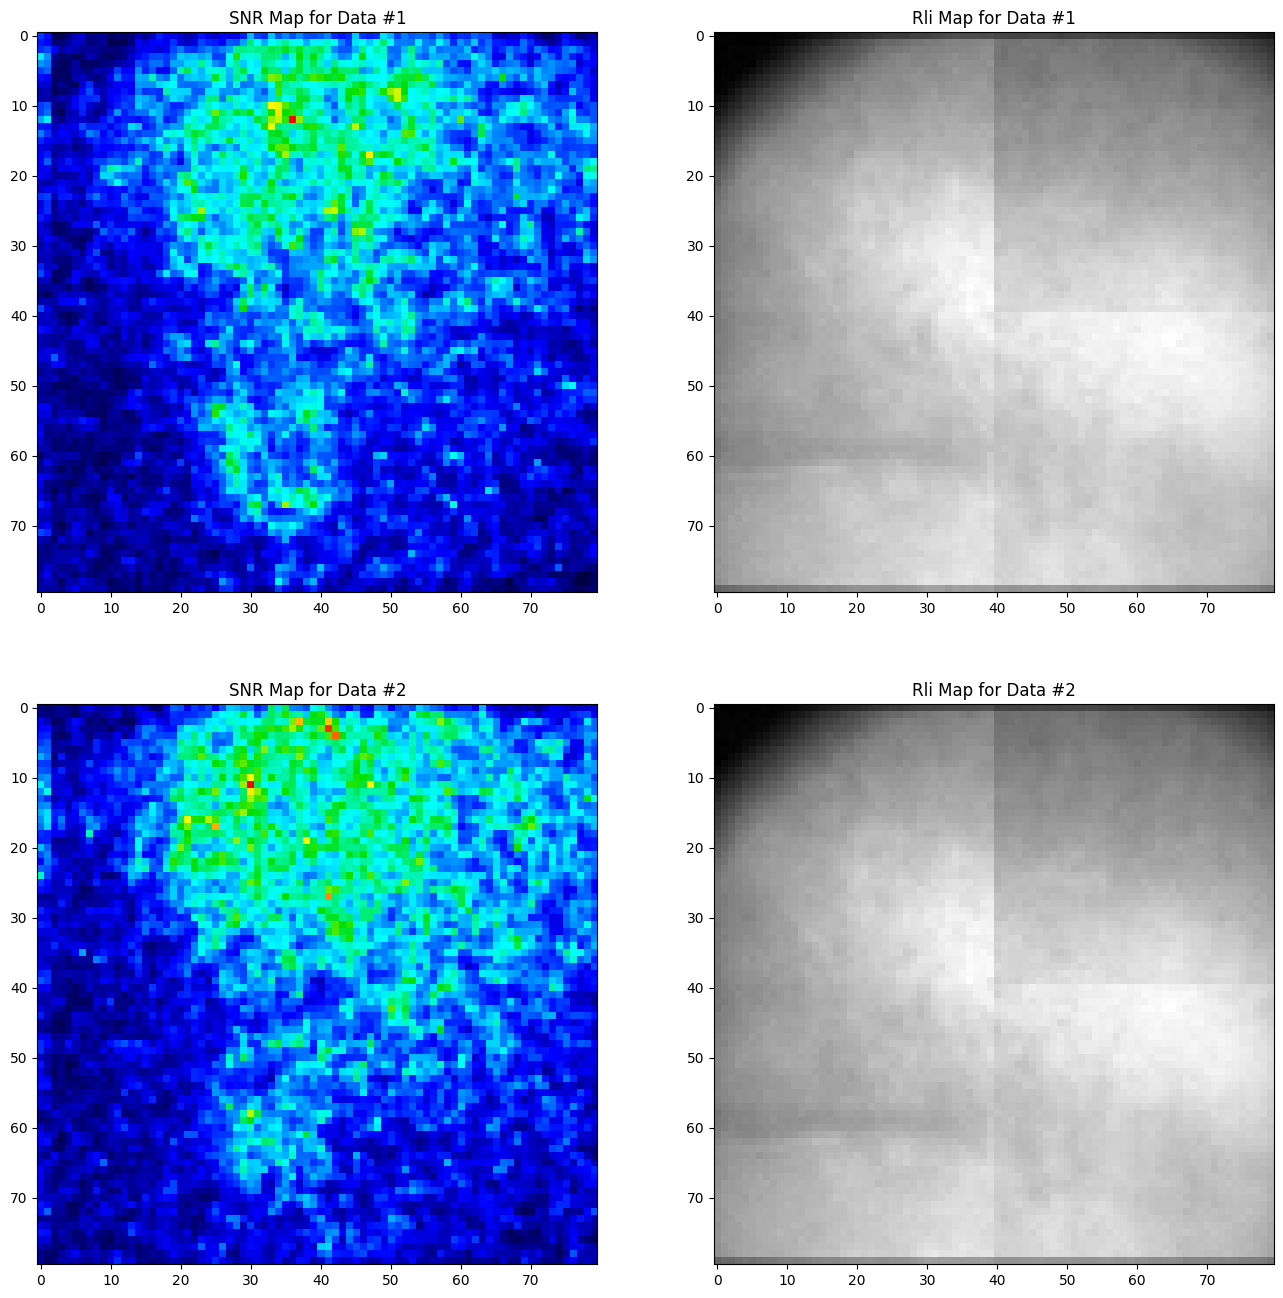

In [6]:
# Plotting the SNR Maps and Rli Maps for Data #1 and Data #2.
plt.subplots(2, 2, figsize=(16, 16))

# SNR Map for Data #1.
ax1 = plt.subplot(2, 2, 1)
ax1.imshow(snr_map_1 / np.max(snr_map_1), vmin=0, vmax=1, cmap=maps.colorbar())
ax1.set_title('SNR Map for Data #1')

# RLi Map for Data #1.
ax2 = plt.subplot(2, 2, 2)
ax2.imshow(rli_1, cmap='gray')
ax2.set_title('Rli Map for Data #1')

# SNR Map for Data #2.
ax3 = plt.subplot(2, 2, 3)
ax3.imshow(snr_map_2 / np.max(snr_map_2), vmin=0, vmax=1, cmap=maps.colorbar())
ax3.set_title('SNR Map for Data #2')

# Rli Map for Data #2.
ax4 = plt.subplot(2, 2, 4)
ax4.imshow(rli_2, cmap='gray')
ax4.set_title('Rli Map for Data #2')

plt.show()

In [7]:
# Single Cell Identification for Data #1.
candidates_1 = identify.candidates(Data_ave=Data_ave_1, cutoff=90, startPt=startPt, numPt=numPt)
candidates_1 = identify.select_non_overlap(candidates=candidates_1, snr_map=snr_map_1)
candidates_1 = sorted(candidates_1, key=lambda x: (x[0], x[1]))

In [8]:
# Single Cell Identification for Data #2.
candidates_2 = identify.candidates(Data_ave=Data_ave_2, cutoff=90, startPt=startPt, numPt=numPt)
candidates_2 = identify.select_non_overlap(candidates=candidates_2, snr_map=snr_map_2)
candidates_2 = sorted(candidates_2, key=lambda x: (x[0], x[1]))

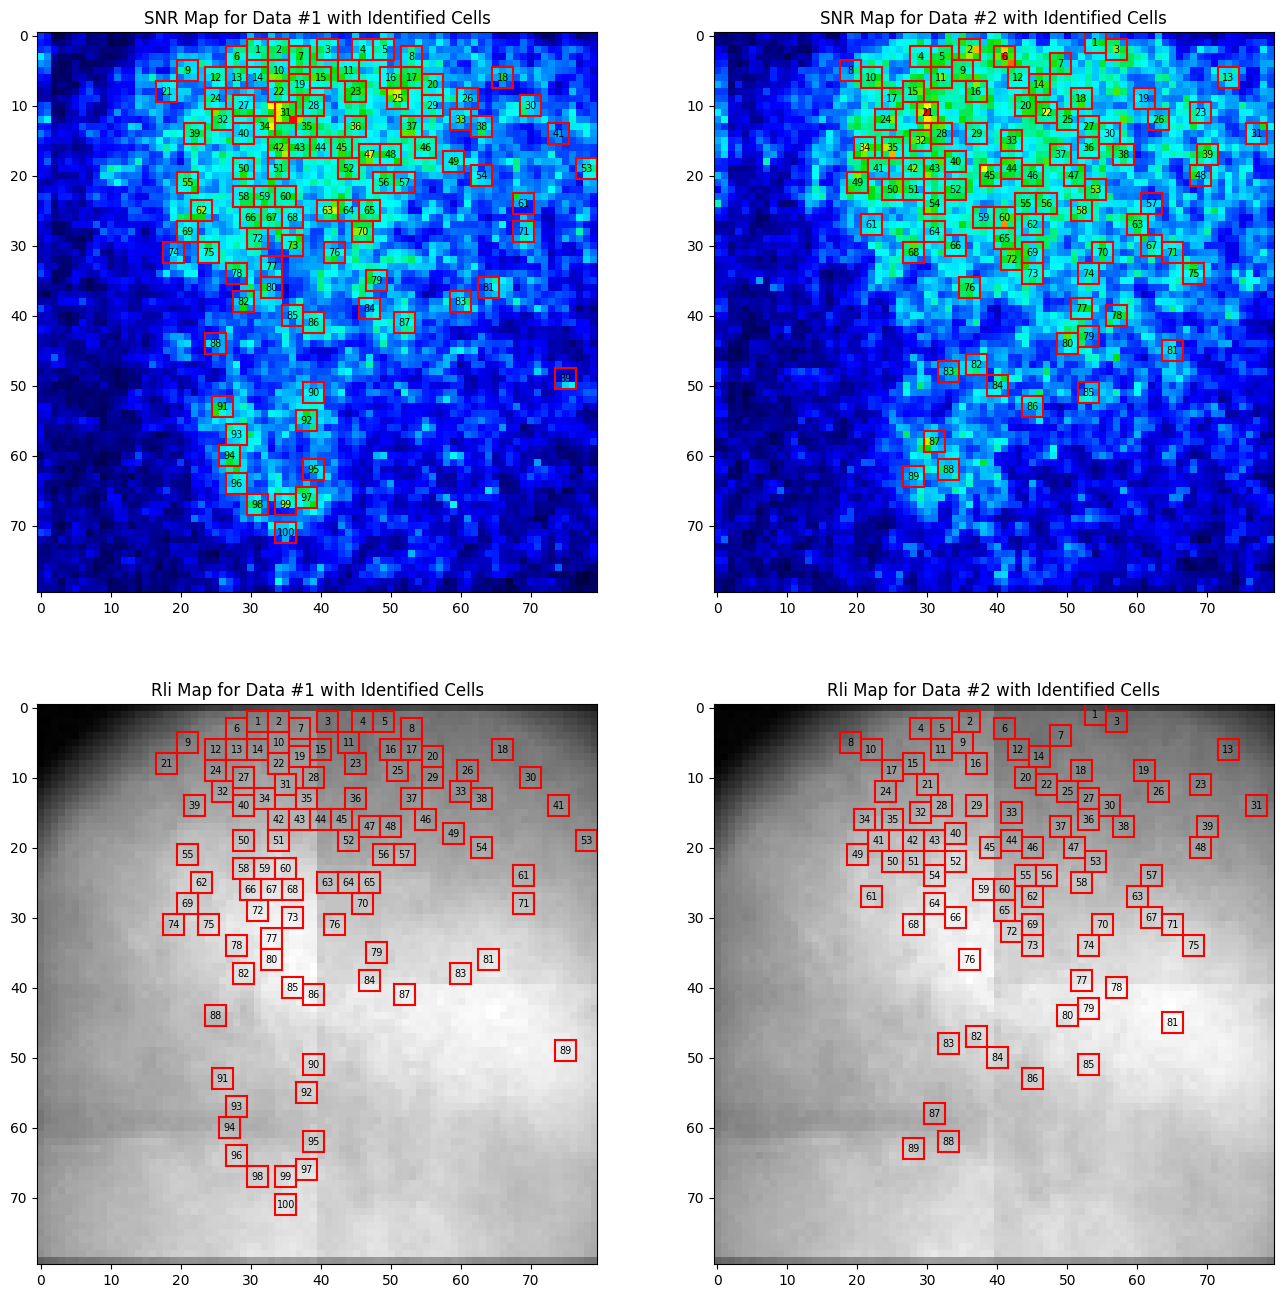

In [9]:
# Parameters setting.
color = 'red'
linewidth = 1.5
index_1 = [(x[0], x[1]) for x in candidates_1]
index_2 = [(x[0], x[1]) for x in candidates_2]

# Visualization of the identified cells on the SNR Maps and Rli Maps for Data #1 and Data #2.
plt.subplots(2, 2, figsize=(16, 16))

# SNR Map for Data #1 with identified cells.
ax1 = plt.subplot(2, 2, 1)
ax1.imshow(snr_map_1 / np.max(snr_map_1), vmin=0, vmax=1, cmap=maps.colorbar())
ax1.set_title('SNR Map for Data #1 with Identified Cells')
for i, coor in enumerate(index_1):

    #  Coordinates for columns and rows.   
    r = coor[1]
    c = coor[0]

    # Pixel boundaries.
    top    = r - 1.5
    bottom = r + 1.5
    left   = c - 1.5
    right  = c + 1.5

    # Draw square contour.
    ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax1.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

# SNR Map for Dasta #2 with identified cells.
ax2 = plt.subplot(2, 2, 2)
ax2.imshow(snr_map_2 / np.max(snr_map_2), vmin=0, vmax=1, cmap=maps.colorbar())
ax2.set_title('SNR Map for Data #2 with Identified Cells')
for i, coor in enumerate(index_2):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax2.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

# Rli Map for Data #1 with identified cells.
ax3 = plt.subplot(2, 2, 3)  
ax3.imshow(rli_1, cmap='gray')
ax3.set_title('Rli Map for Data #1 with Identified Cells')
for i, coor in enumerate(index_1):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax3.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax3.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax3.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax3.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax3.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

# Rli Map for Data #2 with identified cells.
ax4 = plt.subplot(2, 2, 4)  
ax4.imshow(rli_2, cmap='gray')
ax4.set_title('Rli Map for Data #2 with Identified Cells')
for i, coor in enumerate(index_2):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax4.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax4.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax4.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax4.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax4.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

plt.show()

Neuron 1 and Neuron 7 are correlated with a positive slope, and the P-Value is: 0.041593 , distance is: 36.49657518178932 um.
Neuron 1 and Neuron 19 are correlated with a positive slope, and the P-Value is: 0.002463 , distance is: 46.861498055439924 um.
Neuron 1 and Neuron 31 are correlated with a positive slope, and the P-Value is: 0.008822 , distance is: 59.093146810776624 um.
Neuron 1 and Neuron 63 are correlated with a positive slope, and the P-Value is: 0.033967 , distance is: 150.47923444781344 um.
Neuron 1 and Neuron 64 are correlated with a positive slope, and the P-Value is: 0.043213 , distance is: 158.51813776347487 um.
Neuron 2 and Neuron 4 are correlated with a positive slope, and the P-Value is: 0.000712 , distance is: 72.0 um.
Neuron 2 and Neuron 53 are correlated with a positive slope, and the P-Value is: 0.020818 , distance is: 283.01943396169816 um.
Neuron 2 and Neuron 90 are correlated with a positive slope, and the P-Value is: 0.005627 , distance is: 295.526648544594

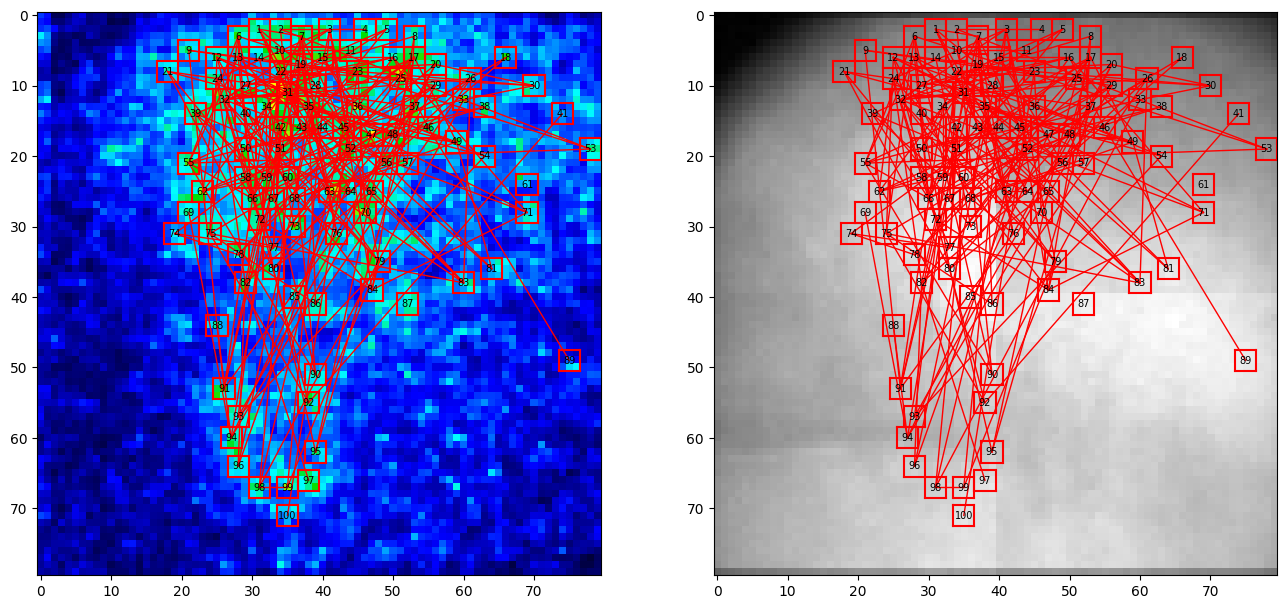

201 pairs are correlated.
Totally 4950 pairs.


In [10]:
length_1 = len(candidates_1)
trial = Data_1.shape[0]
latency_1 = np.zeros((length_1, trial))
connection_1 = np.zeros(length_1, dtype=int)
count = 0

plt.subplots(1, 2, figsize=(16,8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
ax1.imshow(snr_map_1 / np.max(snr_map_1), vmin=0, vmax=1, cmap=maps.colorbar())
ax2.imshow(rli_1, cmap='gray')

for i, coor in enumerate(index_1):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax1.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')
    ax2.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

for i in range(length_1):
    for j in range(trial):
        
        data_tem = []
        for coor in candidates_1[i][3]:
            data_tem.append(Data_1[j, coor[0], coor[1], :])
        data_tem = np.array(data_tem)
        Trace = np.mean(data_tem, axis=0)
        latency_1[i][j] = maps.Half_Amp_Latency(Trace=Trace, startPt=startPt, numPt=numPt)

for i in range(length_1-1):
    for j in range(i+1, length_1):
        
        dist = np.sqrt((index_1[i][0] - index_1[j][0])**2 + (index_1[i][1] - index_1[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_1[i], latency_1[j])
        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', i+1, 'and Neuron', j+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index_1[i]
            loc_2 = index_1[j]
            connection_1[i] = connection_1[i] + 1
            connection_1[j] = connection_1[j] + 1
            ax1.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)
            ax2.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

plt.show()

print(count, 'pairs are correlated.')
print('Totally', int(length_1*(length_1-1)/2), 'pairs.')

In [11]:
np.mean(connection_1)

np.float64(4.02)

Neuron 1 and Neuron 15 are correlated with a positive slope, and the P-Value is: 0.035126 , distance is: 161.55494421403512 um.
Neuron 1 and Neuron 62 are correlated with a positive slope, and the P-Value is: 0.048748 , distance is: 165.08179790637126 um.
Neuron 1 and Neuron 70 are correlated with a positive slope, and the P-Value is: 0.022729 , distance is: 180.0999722376436 um.
Neuron 2 and Neuron 54 are correlated with a positive slope, and the P-Value is: 0.001897 , distance is: 135.36617007214173 um.
Neuron 2 and Neuron 86 are correlated with a positive slope, and the P-Value is: 0.028408 , distance is: 310.72817702937726 um.
Neuron 3 and Neuron 4 are correlated with a positive slope, and the P-Value is: 0.013506 , distance is: 168.1071087134628 um.
Neuron 3 and Neuron 55 are correlated with a positive slope, and the P-Value is: 0.012905 , distance is: 153.32318807016765 um.
Neuron 4 and Neuron 16 are correlated with a positive slope, and the P-Value is: 0.006047 , distance is: 56

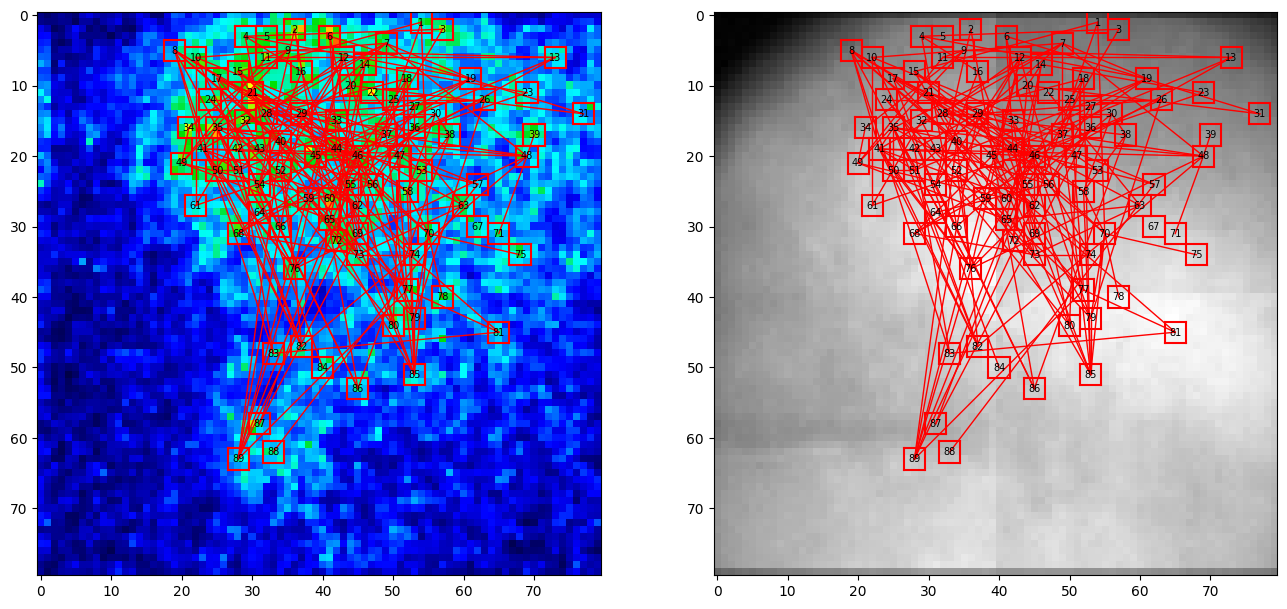

176 pairs are correlated.
Totally 3916 pairs.


In [12]:
length_2 = len(candidates_2)
trial = Data_2.shape[0]
latency_2 = np.zeros((length_2, trial))
connection_2 = np.zeros(length_2, dtype=int)
count = 0

plt.subplots(1, 2, figsize=(16,8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
ax1.imshow(snr_map_2 / np.max(snr_map_2), vmin=0, vmax=1, cmap=maps.colorbar())
ax2.imshow(rli_2, cmap='gray')

for i, coor in enumerate(index_2):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax1.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')
    ax2.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

for i in range(length_2):
    for j in range(trial):
        
        data_tem = []
        for coor in candidates_2[i][3]:
            data_tem.append(Data_2[j, coor[0], coor[1], :])
        data_tem = np.array(data_tem)
        Trace = np.mean(data_tem, axis=0)
        latency_2[i][j] = maps.Half_Amp_Latency(Trace=Trace, startPt=startPt, numPt=numPt)

for i in range(length_2-1):
    for j in range(i+1, length_2):
        
        dist = np.sqrt((index_2[i][0] - index_2[j][0])**2 + (index_2[i][1] - index_2[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_2[i], latency_2[j])
        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', i+1, 'and Neuron', j+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index_2[i]
            loc_2 = index_2[j]
            connection_2[i] = connection_2[i] + 1
            connection_2[j] = connection_2[j] + 1
            ax1.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)
            ax2.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

plt.show()

print(count, 'pairs are correlated.')
print('Totally', int(length_2*(length_2-1)/2), 'pairs.')

In [13]:
np.mean(connection_2)

np.float64(3.955056179775281)

Neuron 1 and Neuron 7 are correlated with a positive slope, and the P-Value is: 0.041593 , distance is: 36.49657518178932 um.
Neuron 1 and Neuron 19 are correlated with a positive slope, and the P-Value is: 0.002463 , distance is: 46.861498055439924 um.
Neuron 1 and Neuron 31 are correlated with a positive slope, and the P-Value is: 0.008822 , distance is: 59.093146810776624 um.
Neuron 1 and Neuron 63 are correlated with a positive slope, and the P-Value is: 0.033967 , distance is: 150.47923444781344 um.
Neuron 1 and Neuron 64 are correlated with a positive slope, and the P-Value is: 0.043213 , distance is: 158.51813776347487 um.


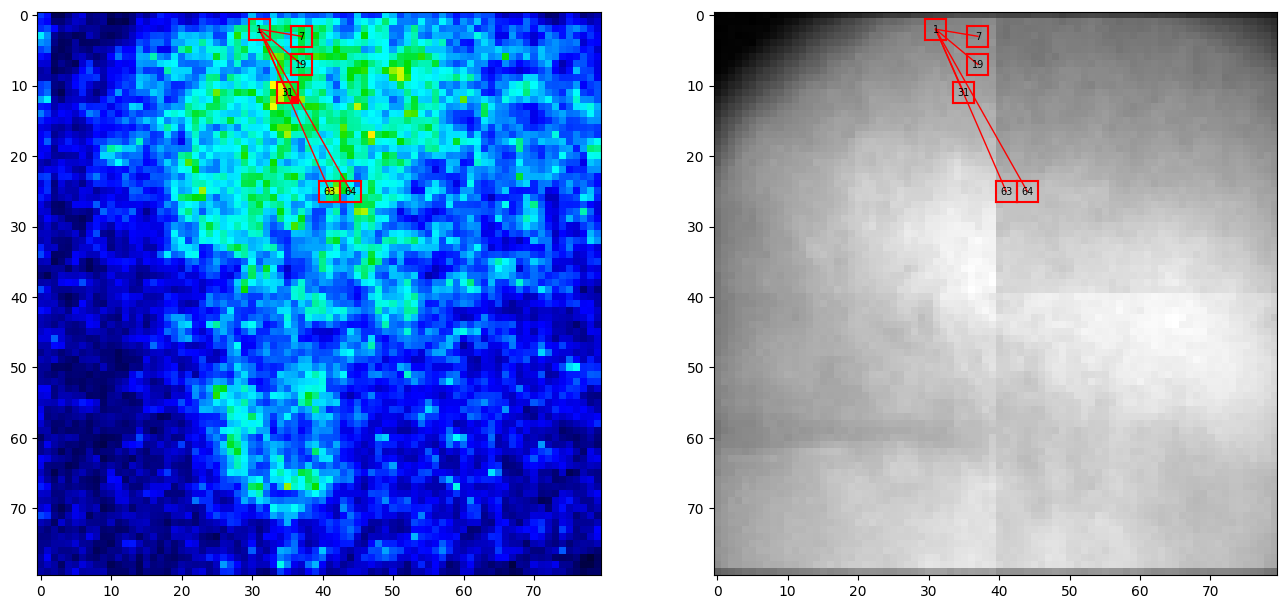

In [14]:
neuro_label_1 = 1

plt.subplots(1, 2, figsize=(16,8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
ax1.imshow(snr_map_1 / np.max(snr_map_1), vmin=0, vmax=1, cmap=maps.colorbar())
ax2.imshow(rli_1, cmap='gray')


top = index_1[neuro_label_1-1][1] - 1.5
bottom = index_1[neuro_label_1-1][1] + 1.5
left = index_1[neuro_label_1-1][0] - 1.5
right = index_1[neuro_label_1-1][0] + 1.5

ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
ax1.annotate(str(neuro_label_1), xy=(index_1[neuro_label_1-1][1], index_1[neuro_label_1-1][0]), ha='center', va='center', fontsize=7, color='black')

ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
ax2.annotate(str(neuro_label_1), xy=(index_1[neuro_label_1-1][1], index_1[neuro_label_1-1][0]), ha='center', va='center', fontsize=7, color='black')

for i in range(length_1):

    if i == neuro_label_1 - 1:
        continue
    else:
        dist = np.sqrt((index_1[i][0] - index_1[neuro_label_1-1][0])**2 + (index_1[i][1] - index_1[neuro_label_1-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_1[i], latency_1[neuro_label_1-1])

        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', neuro_label_1, 'and Neuron', i+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index_1[i]
            loc_2 = index_1[neuro_label_1-1]

            ax1.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)
            ax2.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
            ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
            ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
            ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
            ax1.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='black')

            ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
            ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
            ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
            ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
            ax2.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='black')

plt.show()

Neuron 1 and Neuron 15 are correlated with a positive slope, and the P-Value is: 0.035126 , distance is: 161.55494421403512 um.
Neuron 1 and Neuron 62 are correlated with a positive slope, and the P-Value is: 0.048748 , distance is: 165.08179790637126 um.
Neuron 1 and Neuron 70 are correlated with a positive slope, and the P-Value is: 0.022729 , distance is: 180.0999722376436 um.


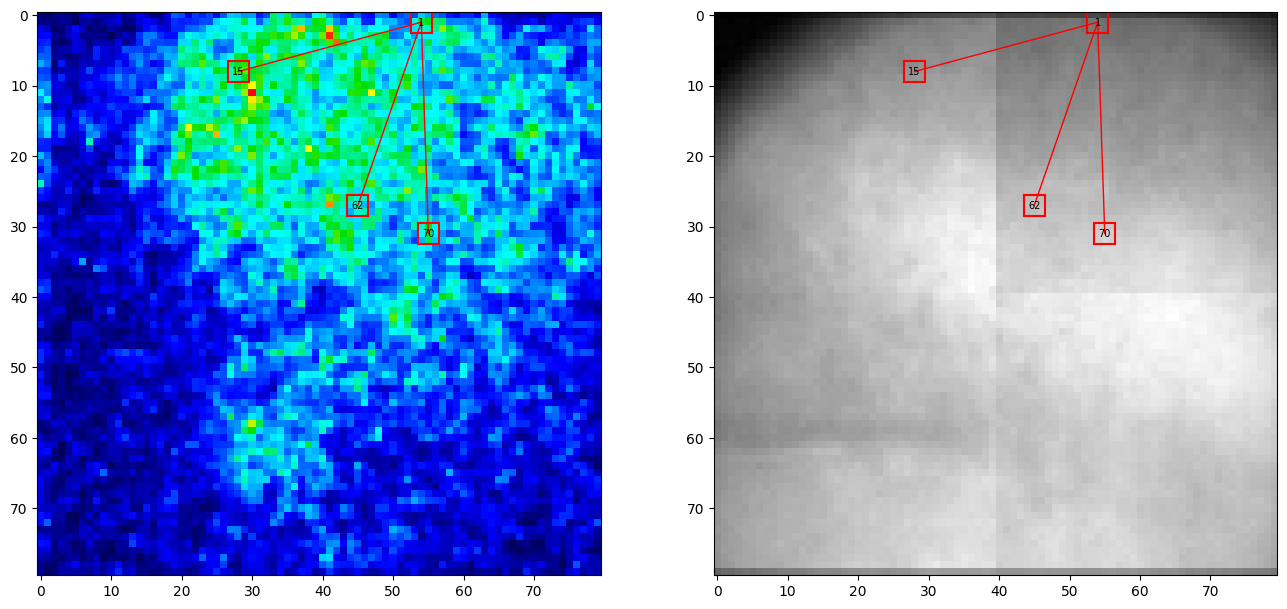

In [15]:
neuro_label_2 = 1

plt.subplots(1, 2, figsize=(16,8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
ax1.imshow(snr_map_2 / np.max(snr_map_2), vmin=0, vmax=1, cmap=maps.colorbar())
ax2.imshow(rli_2, cmap='gray')

top = index_2[neuro_label_2-1][1] - 1.5
bottom = index_2[neuro_label_2-1][1] + 1.5
left = index_2[neuro_label_2-1][0] - 1.5
right = index_2[neuro_label_2-1][0] + 1.5

ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
ax1.annotate(str(neuro_label_2), xy=(index_2[neuro_label_2-1][1], index_2[neuro_label_2-1][0]), ha='center', va='center', fontsize=7, color='black')

ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
ax2.annotate(str(neuro_label_2), xy=(index_2[neuro_label_2-1][1], index_2[neuro_label_2-1][0]), ha='center', va='center', fontsize=7, color='black')

for i in range(length_2):

    if i == neuro_label_2 - 1:
        continue
    else:
        dist = np.sqrt((index_2[i][0] - index_2[neuro_label_2-1][0])**2 + (index_2[i][1] - index_2[neuro_label_2-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_2[i], latency_2[neuro_label_2-1])

        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', neuro_label_2, 'and Neuron', i+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index_2[i]
            loc_2 = index_2[neuro_label_2-1]

            ax1.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)
            ax2.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
            ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
            ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
            ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
            ax1.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='black')

            ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
            ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
            ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
            ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
            ax2.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='black')

plt.show()     